In [38]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import os

from PIL import Image
import pyarrow as pa

meta_data = load_dataset("marco-schouten/hidden-objects")


In [22]:
from adlcv_project.data import HiddenObjectsDatasetStreaming

dataset = HiddenObjectsDatasetStreaming("../data/")

In [59]:
dataset.hf_data[30]

{'entry_id': 2,
 'bg_path': 'data_large_standard/w/wave/00002144.jpg',
 'fg_class': 'surfboard',
 'bbox': [0.316406, 0.328125, 0.152344, 0.269531],
 'label': 1,
 'image_reward_score': -0.793100893497467,
 'confidence': 0.3901195526123047,
 'source': 'ho'}

In [62]:
def get_filtered_data(bg_path, fg_class, label=1):
    return dataset.hf_data.filter(
        lambda x: (x['bg_path'] == bg_path)
        and 
        (x['fg_class'] == fg_class)
        and
        (x['label'] == label)
    )

def center_crop_512(img, img_size):
    w, h = img.size
    left, top = (w - img_size) // 2, (h - img_size) // 2
    return img.crop((left, top, left + img_size, top + img_size))

def get_heatmap(rows, img_size):
    blank_img = np.zeros((img_size, img_size), dtype=np.float64)

    for row in rows:
        x, y, w, h = row["bbox"]
        x = int(x * img_size)
        y = int(y * img_size)
        w = int(w * img_size)
        h = int(h * img_size)

        blank_img[y:y+h, x:x+w] += -row["image_reward_score"]

    return blank_img


In [60]:
filtered_data_bottle = get_filtered_data(
    bg_path="data_large_standard/k/kitchen/00002986.jpg",
    fg_class="bottle",
)

filtered_data_surfboard = get_filtered_data(
    bg_path="data_large_standard/w/wave/00002144.jpg",
    fg_class="surfboard",
)

Filter: 100%|██████████| 15917203/15917203 [01:43<00:00, 153786.08 examples/s]


In [82]:


IMG_SIZE = 512
DEMO_DIR = "../data/"
bg_path = 'data_large_standard/k/kitchen/00002986.jpg'




def plot(filtered_data, bg_path, fg_class):
    img_og = Image.open(os.path.join(DEMO_DIR, bg_path)).convert("RGB")
    img = center_crop_512(img_og, IMG_SIZE)

    rows = []

    for _dict_item in filtered_data:
        _dict_item = dict(_dict_item)
        rows.append({
            "bbox": _dict_item["bbox"],
            "image_reward_score": _dict_item["image_reward_score"],
        })


    fig, axes = plt.subplots(1, 4, figsize=(15, 5 * 1))


    axes[0].imshow(img_og)
    axes[0].set_title("Original Image")
    axes[0].axis('off')
    axes[1].imshow(img)
    axes[1].set_title("Center Cropped Image")
    axes[1].axis('off')

    top_rows = sorted(rows, key=lambda r: -r["image_reward_score"])[:100]
    for r in top_rows:
        x, y, w, h = r["bbox"]
        rect = patches.Rectangle(
            (x * IMG_SIZE, y * IMG_SIZE), w * IMG_SIZE, h * IMG_SIZE,
            linewidth=2, edgecolor="lime", facecolor="none",
        )
        axes[2].add_patch(rect)

    axes[2].imshow(img)
    axes[2].axis('off')
    axes[2].set_title("Top 10 Bounding Boxes for 'bottle'")

    blank_img = get_heatmap(rows, IMG_SIZE)

    #axes[3].imshow(img)
    axes[3].axis('off')
    axes[3].set_title("Heatmap of Image Reward Scores")
    # colorbar
    im = axes[3].imshow(blank_img, cmap='hot', alpha=1.0)
    fig.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)
    plt.show()


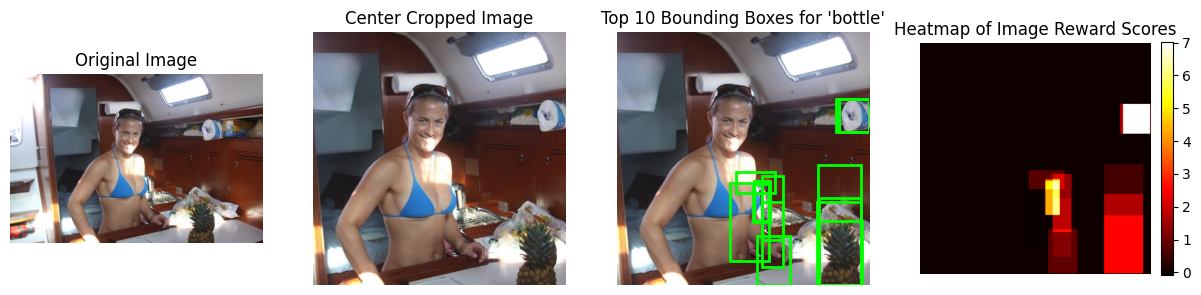

In [83]:
plot(
    filtered_data_bottle,
    bg_path="data_large_standard/k/kitchen/00002986.jpg",
    fg_class="bottle"
)

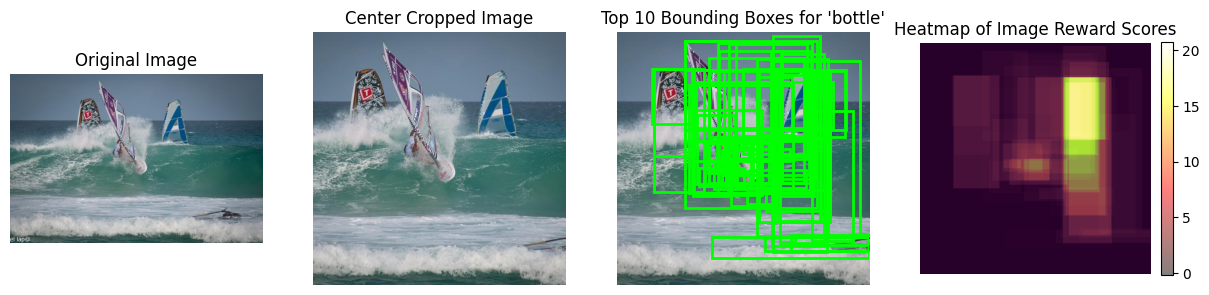

In [67]:
plot(
    filtered_data_surfboard,
    bg_path="data_large_standard/w/wave/00002144.jpg",
    fg_class="surfboard"
)